# Slowly Changing Dimensions (SCD) para Recursos Humanos

## Integrantes Grupo #3
- Beatriz Eunice Beltrán López
- Brenda Nicole Henríquez Amaya
- Jonathan Vladimir Montes Rodriguez

## Objetivo
Desarrollar un sistema SCD para Recursos Humanos utilizando SQL, permitiendo gestionar cambios históricos mediante SCD Tipo 1, Tipo 2 y Tipo 3.

# Diagrama Entidad Relación

A continuación se presenta el DER utilizado para el sistema SCD.

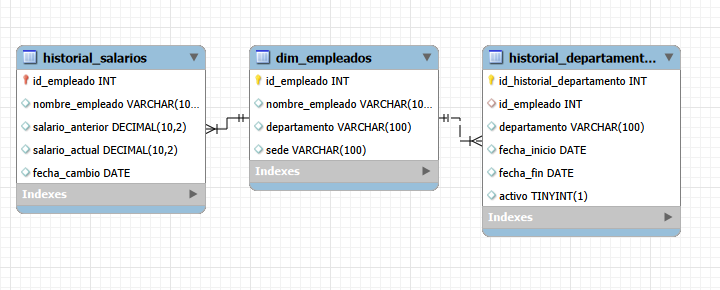

### Explicación del Diagrama Entidad Relación

La tabla `historial_salarios` se relaciona con la tabla `dim_empleados` mediante una llave foránea (`FOREIGN KEY`) utilizando el campo `id_empleado`. Esto permite mantener integridad referencial entre los empleados y su información salarial.

Además, la tabla conserva el campo `nombre_empleado` con fines prácticos y de visualización dentro del proyecto, facilitando la lectura de los registros y el análisis de la evolución salarial en el notebook.

Esta tabla fue utilizada para implementar SCD Tipo 3, almacenando el salario actual y el salario anterior dentro de una misma fila para comparar cambios recientes sin generar nuevos registros históricos.


# 1. Creación de la Base de Datos

```sql
-- CREACION DE LA BASE DE DATOS:
CREATE DATABASE IF NOT EXISTS scd_db;

-- SELECCIÓN DE LA BASE DE DATOS:
USE scd_db;
```

# 2. Creación de la Dimensión Empleados — Nicole

### Tabla dimensión empleados

```sql
CREATE TABLE IF NOT EXISTS dim_empleados (
    id_empleado INT PRIMARY KEY,
    nombre_empleado VARCHAR(100),
    departamento VARCHAR(100),
    sede VARCHAR(100)
);

```

### Inserts

```sql
USE scd_db;

-- Inserción segura de los 5 registros iniciales oficiales
INSERT INTO dim_empleados (id_empleado, nombre_empleado, departamento, sede)
VALUES
(1, 'Juan Pérez', 'Ventas', 'San Salvador'),
(2, 'Ana López', 'Recursos Humanos', 'Santa Ana'),
(3, 'Luis Martínez', 'Finanzas', 'Sonsonate'),
(4, 'María Gómez', 'Marketing', 'La Libertad'),
(5, 'Carlos Rivera', 'IT', 'San Miguel')
ON DUPLICATE KEY UPDATE id_empleado = id_empleado;
```

### Consulta de verificación de datos

```sql
SELECT id_empleado, nombre_empleado, departamento, sede 
FROM dim_empleados;
```

### Evidencia de resultados

- Resultado mostrado directamente en notebook, ejemplo: (borren esto y sustituyanlo por su tabla)

| id_empleado | nombre_empleado | departamento | sede |
| :--- | :--- | :--- | :--- |
| 1 | Juan Pérez | Ventas | San Salvador |
| 2 | Ana López | Recursos Humanos | Santa Ana |
| 3 | Luis Martínez | Finanzas | Sonsonate |
| 4 | María Gómez | Marketing | La Libertad |
| 5 | Carlos Rivera | IT | San Miguel |

# 3. Creación del Historial de Departamentos — Jonathan

### Tabla historial_departamentos

```sql
CREATE TABLE historial_departamentos (
    id_historial_departamento INT PRIMARY KEY AUTO_INCREMENT,
    id_empleado INT,
    departamento VARCHAR(100),
    fecha_inicio DATE,
    fecha_fin DATE,
    activo BOOLEAN,
    
    FOREIGN KEY (id_empleado)
    REFERENCES dim_empleados(id_empleado)
);

```

### Inserts

```sql
INSERT INTO historial_departamentos (
    id_empleado,
    departamento,
    fecha_inicio,
    fecha_fin,
    activo
)
VALUES
(1, 'Ventas', '2025-01-01', NULL, TRUE),
(2, 'Recursos Humanos', '2025-01-01', NULL, TRUE),
(3, 'Finanzas', '2025-01-01', NULL, TRUE),
(4, 'Marketing', '2025-01-01', NULL, TRUE),
(5, 'IT', '2025-01-01', NULL, TRUE);

```

### Consulta de verificación de datos

```sql
SELECT * FROM historial_departamentos;

```

### Evidencia de resultados

| id_historial_departamento | id_empleado | departamento | fecha_inicio | fecha_fin | activo |
| --- | --- | --- | --- | --- | --- |
| 1 | 1 | Ventas | 2025-01-01 | 2026-05-25 | 0 |
| 2 | 2 | Recursos Humanos | 2025-01-01 | | 1 |
| 3 | 3 | Finanzas | 2025-01-01 | | 1 |
| 4 | 4 | Marketing | 2025-01-01 | | 1 |
| 5 | 5 | IT | 2025-01-01 | | 1 |
| 6 | 1 | IT | 2026-05-25 | | 1 |


# 4. Creación del Historial Salarial — Eunice

### Tabla historial_salarios

```sql
CREATE TABLE historial_salarios (
    id_empleado INT PRIMARY KEY,
    nombre_empleado VARCHAR(100),
    salario_anterior DECIMAL(10,2),
    salario_actual DECIMAL(10,2),
    fecha_cambio DATE,

    FOREIGN KEY (id_empleado)
    REFERENCES dim_empleados(id_empleado)
);
```

### Inserts

```sql
INSERT INTO historial_salarios (
    id_empleado,
    nombre_empleado,
    salario_anterior,
    salario_actual,
    fecha_cambio
)
VALUES
(1, 'Juan Pérez', NULL, 800.00, '2025-01-01'),
(2, 'Ana López', NULL, 950.00, '2025-01-01'),
(3, 'Luis Martínez', NULL, 1100.00, '2025-01-01'),
(4, 'María Gómez', NULL, 1000.00, '2025-01-01'),
(5, 'Carlos Rivera', NULL, 1200.00, '2025-01-01');
```

### Consulta de verificación de datos

```sql
SELECT * FROM historial_salarios;
```

### Evidencia de resultados

| id_empleado | nombre_empleado | salario_anterior | salario_actual | fecha_cambio |
|---|---|---|---|---|
| 1 | Juan Pérez | NULL | 800.00 | 2025-01-01 |
| 2 | Ana López | NULL | 950.00 | 2025-01-01 |
| 3 | Luis Martínez | NULL | 1100.00 | 2025-01-01 |
| 4 | María Gómez | NULL | 1000.00 | 2025-01-01 |
| 5 | Carlos Rivera | NULL | 1200.00 | 2025-01-01 |

# 5. Implementación SCD Tipo 1 — Nicole

# SCD Tipo 1 — Nicole

En el SCD Tipo 1:

- el dato anterior se sobrescribe,
- no se conserva historial.

### Update de sobrescritura

```sql
USE scd_db;

-- El departamento anterior 'Recursos Humanos' se sobrescribe por completo
UPDATE dim_empleados
SET departamento = 'Operaciones'
WHERE id_empleado = 2;

```

### Consulta de verificación

```sql
SELECT id_empleado, nombre_empleado, departamento, sede 
FROM dim_empleados 
WHERE id_empleado = 2;
```

### Evidencia de resultados

| id_empleado | nombre_empleado | departamento | sede |
| :--- | :--- | :--- | :--- |
| 2 | Ana López | Operaciones | Santa Ana |

### Análisis del comportamiento del SCD Tipo 1

# 6. Implementación SCD Tipo 2 — Jonathan


En el SCD Tipo 2:

- se conserva historial completo,
- se crea un nuevo registro.

### Nuevos campos utilizados

```text
- dapartamento
- fecha_inicio
- activo
```

### Update de registro anterior

```sql
UPDATE historial_departamentos
SET fecha_fin = CURRENT_DATE,
    activo = FALSE
WHERE id_empleado = 1
AND activo = TRUE;
```

### Insert de nuevo registro histórico

```sql
INSERT INTO historial_departamentos (
    id_empleado,
    departamento,
    fecha_inicio,
    fecha_fin,
    activo
)
VALUES (
    1,
    'IT',
    CURRENT_DATE,
    NULL,
    TRUE
);

```

### Consulta de verificación histórica

```sql
SELECT *
FROM historial_departamentos
WHERE id_empleado = 1;
```

### Evidencia de resultados

- Resultado mostrado directamente en notebook, ejemplo: (borren esto y sustituyanlo por su tabla)

| id_historial_departamento | id_empleado | departamento | fecha_inicio | fecha_fin | activo |
|---|---|---|---|---|---|
|1|1|Ventas|2025-01-01|2026-05-25|0|
|6|1|IT|2026-05-25|NULL|1|

### Análisis del comportamiento del SCD Tipo 2
La implementación del SCD Tipo 2 permitió conservar el historial completo de cambios de departamento de los empleados. Para ello, se cerró el registro anterior utilizando una fecha de finalización y se creó un nuevo registro histórico con el departamento actualizado. Este enfoque permitió mantener trazabilidad completa de los cambios organizacionales realizados.

# 7. Implementación SCD Tipo 3 — Eunice

En el SCD Tipo 3:

- únicamente se conserva un cambio anterior.

### Update salarial

```sql
UPDATE historial_salarios
SET salario_anterior = salario_actual,
    salario_actual = 1200.00,
    fecha_cambio = CURRENT_DATE
WHERE id_empleado = 1;
```

### Consulta de verificación salarial

```sql
-- - Consultar valores actuales y anteriores
select * from historial_salarios;
```

### Evidencia de resultados

| id_empleado | nombre_empleado | salario_anterior | salario_actual | fecha_cambio |
|---|---|---|---|---|
| 1 | Juan Pérez | 800.00 | 1200.00 | 2026-05-24 |
| 2 | Ana López | NULL | 950.00 | 2025-01-01 |
| 3 | Luis Martínez | NULL | 1100.00 | 2025-01-01 |
| 4 | María Gómez | NULL | 1000.00 | 2025-01-01 |
| 5 | Carlos Rivera | NULL | 1200.00 | 2025-01-01 |

### Análisis del comportamiento del SCD Tipo 3
Antes de la actualización, el empleado Juan Pérez tenía un salario actual de 800.00. Después de ejecutar la consulta, el salario actual pasó a ser 1200.00 y el valor anterior fue almacenado en la columna salario_anterior.

Este comportamiento demuestra el funcionamiento del SCD Tipo 3, ya que:

- se conserva únicamente el valor anterior,
- el nuevo valor sobrescribe el dato actual,
- y no se crean nuevos registros históricos.

# 8. Simulación de Cambios Organizacionales — Nicole, Jonathan y Eunice

## Cambios de Departamento — Jonathan

### Simulación y consulta

```sql
UPDATE historial_departamentos
SET fecha_fin = CURRENT_DATE,
    activo = FALSE
WHERE id_empleado = 1
AND activo = TRUE;

INSERT INTO historial_departamentos (
    id_empleado,
    departamento,
    fecha_inicio,
    fecha_fin,
    activo
)
VALUES (
    1,
    'IT',
    CURRENT_DATE,
    NULL,
    TRUE
);

SELECT *
FROM historial_departamentos
WHERE id_empleado = 1;
```

### Evidencia de resultados
| id_historial_departamento | id_empleado | departamento | fecha_inicio | fecha_fin | activo |
| --- | --- | --- | --- | --- | --- |
| 1 | 1 | Ventas | 2025-01-01 | 2026-05-25 | 0 |
| 6 | 1 | IT | 2026-05-25 | 2026-05-25 | 0 |
| 7 | 1 | IT | 2026-05-25 | | 1 |

### Explicación de la simulación
En esta simulación se realizó el cambio de departamento de un empleado utilizando SCD Tipo 2. El proceso consistió en desactivar el registro anterior y registrar un nuevo departamento como activo. De esta manera, fue posible conservar el historial de departamentos y analizar los cambios organizacionales ocurridos dentro de la empresa.

---

## Aumentos Salariales — Eunice

### Simulación y consulta

```sql
-- Aumentar salario a la empleada Ana López a 1000
UPDATE historial_salarios
SET salario_anterior = salario_actual,
	salario_actual = 1000,
    fecha_cambio = CURRENT_DATE
WHERE id_empleado = 2;
    
-- Aumentar salario al empleado Luis Martinez a 2000
UPDATE historial_salarios
SET salario_anterior = salario_actual,
	salario_actual = 2000,
    fecha_cambio = CURRENT_DATE
WHERE id_empleado = 3;

```

### Evidencia de resultados

| id_empleado | nombre_empleado | salario_anterior | salario_actual | fecha_cambio |
|---|---|---|---|---|
| 1 | Juan Pérez | 800.00 | 1200.00 | 2026-05-24 |
| 2 | Ana López | 950.00 | 1000.00 | 2026-05-24 |
| 3 | Luis Martínez | 1100.00 | 2000.00 | 2026-05-24 |
| 4 | María Gómez | NULL | 1000.00 | 2025-01-01 |
| 5 | Carlos Rivera | NULL | 1200.00 | 2025-01-01 |

### Explicación de la simulación
En esta simulación se realizaron aumentos salariales a los empleados Ana López y Luis Martínez utilizando SCD Tipo 3.

La implementación consistió en conservar el salario anterior en la columna salario_anterior y actualizar el nuevo valor en la columna salario_actual, manteniendo ambos datos dentro de la misma fila.

Este comportamiento permite comparar fácilmente el salario anterior y el salario actual del empleado sin crear nuevos registros históricos. Sin embargo, únicamente se conserva el cambio más reciente, por lo que el historial almacenado es limitado.

---

## Cambios de Sede — Nicole

### Simulación y consulta

```sql
UPDATE dim_empleados
SET sede = 'San Miguel'
WHERE id_empleado = 1;
-- Consulta
SELECT id_empleado, nombre_empleado, departamento, sede 
FROM dim_empleados;

```

### Evidencia de resultados

| id_empleado | nombre_empleado | departamento | sede |
| :--- | :--- | :--- | :--- |
| 1 | Juan Pérez | Ventas | San Miguel |
| 2 | Ana López | Operaciones | Santa Ana |
| 3 | Luis Martínez | Finanzas | Sonsonate |
| 4 | María Gómez | Marketing | La Libertad |
| 5 | Carlos Rivera | IT | San Miguel |
|
### Explicación de la simulación
Antes de la actualización, el empleado Juan Pérez tenía una sede actual de "San Salvador". Después de ejecutar la consulta, la sede actual pasó a ser "San Miguel" y el valor anterior fue completamente eliminado del registro.

Este comportamiento demuestra el funcionamiento del SCD Tipo 1: el dato anterior se sobrescribe,   no se conserva historial en la tabla,   y optimiza el almacenamiento al no generar nuevas filas.

# 9. Análisis — Nicole, Jonathan y Eunice

## Diferencias Históricas — Jonathan


### Consulta de análisis

```sql
-- Mostrar departamentos anteriores

SELECT
    id_empleado,
    departamento,
    fecha_inicio,
    fecha_fin
FROM historial_departamentos
WHERE activo = FALSE;
```

### Evidencia de resultados
| id_empleado | departamento | fecha_inicio | fecha_fin |
|---|---|---|---|
| 1 | Ventas | 2025-01-01 | 2026-05-25 |
| 1 | IT | 2026-05-25 | 2026-05-25 |

### Interpretación del análisis histórico
El análisis histórico permitió identificar los cambios de departamento realizados a los empleados utilizando SCD Tipo 2. 

Mediante las consultas realizadas fue posible visualizar tanto los registros activos como los registros históricos, permitiendo comparar departamentos anteriores y actuales de cada empleado.

Los resultados demostraron que el SCD Tipo 2 conserva completamente el historial de cambios organizacionales mediante nuevos registros históricos, facilitando la trazabilidad y el análisis temporal de la información dentro de la empresa.

---

## Evolución Salarial — Eunice

### Consulta de análisis

```sql
SELECT 
    nombre_empleado,
    salario_anterior,
    salario_actual,
    (salario_actual - salario_anterior) AS aumento
FROM historial_salarios
WHERE salario_anterior IS NOT NULL;
```

### Evidencia de resultados

| nombre_empleado | salario_anterior | salario_actual | aumento |
| --------------- | ---------------- | -------------- | ------- |
| Juan Pérez      | 800.00           | 1200.00        | 400.00  |
| Ana López       | 950.00           | 1000.00        | 50.00   |
| Luis Martínez   | 1100.00          | 2000.00        | 900.00  |


### Interpretación de evolución salarial

- análisis de aumentos salariales,
- comparación de salarios,
- interpretación de cambios,
- conclusiones salariales.

El análisis de evolución salarial permitió identificar los aumentos aplicados a los empleados dentro del sistema de Recursos Humanos utilizando SCD Tipo 3.

Mediante las consultas realizadas se comparó el salario anterior con el salario actual de cada empleado, permitiendo observar los cambios salariales generados después de las actualizaciones realizadas.

Los resultados mostraron que los empleados Juan Pérez, Ana López y Luis Martínez recibieron aumentos salariales, evidenciando una evolución positiva en sus salarios actuales con respecto a los valores anteriores.

Además, el uso de SCD Tipo 3 permitió conservar el salario anterior dentro de la misma fila, facilitando la comparación directa entre ambos valores sin necesidad de crear nuevos registros históricos.

Sin embargo, se identificó que este tipo de implementación únicamente conserva el cambio más reciente, por lo que no mantiene un historial completo de todas las modificaciones salariales realizadas a lo largo del tiempo.

En conclusión, el SCD Tipo 3 resulta útil para analizar cambios recientes de salario y realizar comparaciones rápidas entre valores anteriores y actuales, especialmente en escenarios donde no se requiere conservar un historial histórico completo.

---

## Cambios Organizacionales — Nicole

### Consulta de análisis

```sql
USE scd_db;

-- consulta
SELECT id_empleado, nombre_empleado, departamento, sede 
FROM dim_empleados;
```

### Evidencia de resultados

| id_empleado | nombre_empleado | departamento | sede |
| :--- | :--- | :--- | :--- |
| 1 | Juan Pérez | Ventas | San Miguel |
| 2 | Ana López | Operaciones | Santa Ana |
| 3 | Luis Martínez | Finanzas | Sonsonate |
| 4 | María Gómez | Marketing | La Libertad |
| 5 | Carlos Rivera | IT | San Miguel |

### Interpretación de cambios organizacionales

- impacto de sobrescritura,
- pérdida de historial,
- consecuencias analíticas,
- comparación con otros tipos SCD.

El análisis de cambios organizacionales permitió identificar las actualizaciones aplicadas a los empleados dentro de la estructura de la empresa utilizando el enfoque SCD Tipo 1, observándose que Ana López y Juan Pérez experimentaron movimientos estratégicos hacia el área de Operaciones y la sede de San Miguel, respectivamente. La implementación de esta técnica mediante sobrescritura directa en la base de datos permitió reflejar la realidad vigente de la organización de manera inmediata sin necesidad de alterar la estructura de claves; sin embargo, debido a la naturaleza estricta de este diseño, los valores previos se destruyeron de forma permanente, generando una pérdida total de historial que impide realizar análisis de trazabilidad temporal. En conclusión, el modelo SCD Tipo 1 demuestra una alta utilidad para optimizar el almacenamiento físico y mantener datos maestros actualizados bajo escenarios operativos donde solo interesa conocer el estado actual y no se requiere conservar un registro histórico completo de las asignaciones.

# 10. Comparación de Tipos SCD — Nicole, Jonathan y Eunice

### Tabla comparativa

| Tipo SCD | Historial | Complejidad | Uso |
|---|---|---|---|
| Tipo 1 | No | Baja | Correcciones |
| Tipo 2 | Sí | Alta | Auditoría e histórico |
| Tipo 3 | Parcial | Media | Comparaciones simples |

---

| Tipo SCD | Característica | Ventaja | Desventaja |
|---|---|---|---|
| Tipo 1 |Sobrescribe los datos existentes directamente en el registro actual.|Optimiza al máximo el almacenamiento físico y es sumamente fácil de implementar.|Destruye la información previa, generando una pérdida total del historial.|
|||||
| Tipo 3 | Conserva valor actual y valor anterior en la misma fila | Permite comparar cambios recientes fácilmente | Solo conserva historial limitado |

### Explicación Final

- Nicole → SCD Tipo 1
- Jonathan → SCD Tipo 2
- Eunice → SCD Tipo 3
En este proyecto, el SCD Tipo 3 fue aplicado en la tabla `historial_salarios`, donde se almacenó el salario actual y el salario anterior de los empleados. Esto permitió analizar fácilmente la evolución salarial y comparar aumentos recientes sin crear nuevos registros históricos.

SCD Tipo 1 fue aplicado en la tabla dim_empleados, donde se actualizaron los departamentos y sedes de forma directa. Esto permitió mantener la dimensión limpia con los datos maestros vigentes de la organización sin necesidad de alterar claves o generar registros duplicados, simplificando la reportería actual a costa de sacrificar la trazabilidad del pasado.

Las tablas comparativas muestran que el SCD Tipo 3 posee una complejidad media, ya que requiere manejar columnas históricas adicionales, pero resulta útil para escenarios donde únicamente se necesita comparar cambios recientes de información.

# 11. Conclusiones — Nicole, Jonathan y Eunice

- Conclusión 1 - Nicole
- Conclusión 2 - Jonathan
- Conclusión 3 - Eunice

La aplicación del modelo SCD Tipo 1 facilitó la actualización inmediata del departamento y la sede de los empleados en una sola fila, asegurando que los reportes reflejen siempre la estructura vigente de la empresa. Este enfoque permitió comprobar cómo mantener la dimensión limpia y optimizada, evitando duplicar registros o sobrecargar el almacenamiento del sistema.

El SCD Tipo 2 permitió conservar el historial completo de cambios de departamento mediante registros históricos, facilitando la trazabilidad, el análisis temporal y la identificación de cambios organizacionales dentro de la empresa.

El SCD Tipo 3 permitió analizar la evolución salarial de los empleados conservando el salario anterior y el salario actual en una misma fila, facilitando comparaciones rápidas de cambios recientes. Además, este tipo de implementación ayudó a comprender cómo manejar historial parcial en sistemas empresariales sin incrementar la cantidad de registros históricos.